# Agent 2 — LSTM Autoencoder Anomaly Detector

**Goal:** Train an unsupervised LSTM Autoencoder that learns normal solar wind patterns.
At inference, high reconstruction error = anomalous conditions = storm building.

```
Normal solar wind  →  low reconstruction error  →  anomaly_score ≈ 0.0
Storm conditions   →  high reconstruction error →  anomaly_score ≈ 1.0
```

**Key idea:** Train ONLY on quiet time data (Dst > -30 nT).
The model never sees storms → can't reconstruct them → flags them as anomalies.

**Output per timestep:**
```json
{
    "anomaly_score": 0.92,
    "storm_probability": "92%",
    "alert_level": "RED",
    "recon_error": 14.3
}
```

**Alert levels:**
- GREEN  (score < 0.40): quiet, Burton reliable
- YELLOW (score 0.40-0.80): onset likely, monitor
- RED    (score > 0.80): storm confirmed, trust LSTM

---
## Instructions
1. Upload `DATA/enriched.parquet` to Google Drive
2. Run all cells top to bottom
3. Save artifacts to Drive and download
4. Place in `models/` folder

## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH  = '/content/drive/MyDrive/enriched.parquet'
MODELS_DIR  = '/content/drive/MyDrive/Solar_Winds/models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)
print(f'Drive mounted. Models will be saved to: {MODELS_DIR}')

Mounted at /content/drive
Drive mounted. Models will be saved to: /content/drive/MyDrive/Solar_Winds/models


## Cell 2 — Check versions

In [2]:
import torch
import pandas as pd
import numpy as np
print(f'PyTorch : {torch.__version__}')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None — enable GPU!"}')

PyTorch : 2.10.0+cu128
Pandas  : 2.2.2
NumPy   : 2.0.2
GPU     : NVIDIA A100-SXM4-40GB


## Cell 3 — Imports

In [3]:
import json, pickle, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Cell 4 — Configuration

In [4]:
# ── Features — raw solar wind only (no Burton-derived features)
# Autoencoder learns raw solar wind patterns, not physics corrections
ANOMALY_FEATURES = [
    'bz_gsm',       # southward Bz drives storms
    'by_gsm',       # y-component
    'bt',           # total magnetic field
    'speed',        # solar wind speed
    'density',      # proton density
    'E_field',      # electric field (V×B)
    'dDst_dt',      # rate of Dst change
    'smoothed_ssn', # solar cycle position
]

# ── Quiet time threshold — train only on normal solar wind ──
QUIET_DST_THRESHOLD = -30.0   # nT — above this = quiet

# ── Hyperparameters ──
SEQ_LEN     = 60      # 1-hour window (autoencoder is lighter than corrector)
LATENT_DIM  = 32      # bottleneck size — smaller = more compression
HIDDEN_SIZE = 64      # LSTM hidden units
NUM_LAYERS  = 2
DROPOUT     = 0.2
BATCH_SIZE  = 1024    # larger batch — simpler task than corrector
LR          = 1e-3
PATIENCE    = 15
MIN_DELTA   = 0.0001
MAX_EPOCHS  = 300

# ── Alert thresholds ──
ALERT_GREEN  = 0.40
ALERT_YELLOW = 0.80

print('Config loaded.')
print(f'Features     : {len(ANOMALY_FEATURES)}')
print(f'SEQ_LEN      : {SEQ_LEN} min')
print(f'Latent dim   : {LATENT_DIM}')
print(f'Quiet thresh : Dst > {QUIET_DST_THRESHOLD} nT')

Config loaded.
Features     : 8
SEQ_LEN      : 60 min
Latent dim   : 32
Quiet thresh : Dst > -30.0 nT


## Cell 5 — Load data & filter quiet time

In [5]:
print('Loading enriched.parquet ...')
df = pd.read_parquet(DRIVE_PATH)
print(f'Full dataset shape: {df.shape}')

# ── Keep quiet time rows only for training ──
# Rows where dst is NaN (non-hourly minutes) OR dst > -30 nT
quiet_mask = df['dst'].isna() | (df['dst'] > QUIET_DST_THRESHOLD)
df_quiet   = df[quiet_mask].copy()
print(f'Quiet time rows  : {len(df_quiet):,}  ({100*len(df_quiet)/len(df):.1f}%)')
print(f'Storm rows (excl): {(~quiet_mask).sum():,}  ({100*(~quiet_mask).sum()/len(df):.1f}%)')

# Fill NaN in features
for col in ANOMALY_FEATURES:
    if df_quiet[col].isna().any():
        df_quiet[col] = df_quiet[col].fillna(df_quiet[col].median())
        print(f'  Filled NaN in {col}')

print(f'\nFeature NaN check: {df_quiet[ANOMALY_FEATURES].isna().sum().sum()}')
print(f'Ready for training.')

Loading enriched.parquet ...
Full dataset shape: (8392320, 25)
Quiet time rows  : 7,475,640  (89.1%)
Storm rows (excl): 916,680  (10.9%)

Feature NaN check: 0
Ready for training.


## Cell 6 — Fit scaler & train/val split

In [6]:
from sklearn.model_selection import train_test_split

# Random 80/20 split — no stratification needed (all quiet time)
train_df, val_df = train_test_split(
    df_quiet, test_size=0.2, random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Train rows : {len(train_df):,}')
print(f'Val rows   : {len(val_df):,}')

# Fit scaler on train only
scaler = StandardScaler()
scaler.fit(train_df[ANOMALY_FEATURES])

train_df[ANOMALY_FEATURES] = scaler.transform(train_df[ANOMALY_FEATURES])
val_df[ANOMALY_FEATURES]   = scaler.transform(val_df[ANOMALY_FEATURES])

print('Scaler fitted on train only (no leakage).')

Train rows : 5,980,512
Val rows   : 1,495,128
Scaler fitted on train only (no leakage).


## Cell 7 — PyTorch Dataset (sliding window, input = target)

In [7]:
class AnomalyDataset(Dataset):
    """
    Sliding window dataset for autoencoder training.
    Input = Target = the same 60-step window.
    Disk mode — slices on-the-fly to avoid RAM crash on 8M rows.
    """
    def __init__(self, df_input, feature_cols, seq_len):
        self.X       = df_input[feature_cols].values.astype(np.float32)
        self.seq_len = seq_len
        self.n       = len(self.X) - seq_len
        print(f'  Dataset size : {self.n:,} windows  (disk mode)')

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx : idx + self.seq_len])
        return x, x   # input = target for autoencoder


print('=== Building train dataset ===')
train_ds = AnomalyDataset(train_df, ANOMALY_FEATURES, SEQ_LEN)

print('\n=== Building val dataset ===')
val_ds = AnomalyDataset(val_df, ANOMALY_FEATURES, SEQ_LEN)

del df, df_quiet, train_df, val_df
gc.collect()
print('\nDataframes freed from RAM.')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nTrain samples : {len(train_ds):,}')
print(f'Val samples   : {len(val_ds):,}')


=== Building train dataset ===
  Dataset size : 5,980,452 windows  (disk mode)

=== Building val dataset ===
  Dataset size : 1,495,068 windows  (disk mode)

Dataframes freed from RAM.

Train samples : 5,980,452
Val samples   : 1,495,068


## Cell 8 — Transformer Autoencoder Architecture

In [8]:
import math

class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class TransformerAutoencoder(nn.Module):
    """
    Transformer Autoencoder for solar wind anomaly detection.

    Encoder: projects input → d_model, applies multi-head self-attention
             to learn which timesteps/features are anomalous.
    Bottleneck: compresses to latent_dim via mean pooling + linear.
    Decoder: expands back, applies self-attention, reconstructs input.

    Input : (batch, seq_len, n_features)
    Output: (batch, seq_len, n_features)  — reconstruction
    """

    def __init__(
        self,
        input_size:  int,
        seq_len:     int,
        d_model:     int = 64,
        latent_dim:  int = 32,
        nhead:       int = 4,
        num_layers:  int = 2,
        dropout:     float = 0.1,
    ):
        super().__init__()

        # ── Input projection ──
        self.input_proj = nn.Linear(input_size, d_model)

        # ── Positional encoding ──
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len + 1, dropout=dropout)

        # ── Transformer Encoder ──
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # ── Bottleneck ──
        self.to_latent   = nn.Linear(d_model, latent_dim)
        self.from_latent = nn.Linear(latent_dim, d_model)

        # ── Transformer Decoder ──
        dec_layer    = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)

        # ── Output projection ──
        self.output_proj = nn.Linear(d_model, input_size)

        self.seq_len   = seq_len
        self.d_model   = d_model
        self.latent_dim = latent_dim

    def encode(self, x):
        """x: (batch, seq_len, input_size) → latent: (batch, seq_len, latent_dim)"""
        x = self.input_proj(x)            # (B, T, d_model)
        x = self.pos_enc(x)
        x = self.encoder(x)               # (B, T, d_model)
        return self.to_latent(x)          # (B, T, latent_dim)

    def decode(self, z, memory):
        """z: (B, T, latent_dim), memory: (B, T, d_model) → (B, T, input_size)"""
        z = self.from_latent(z)           # (B, T, d_model)
        z = self.pos_enc(z)
        z = self.decoder(z, memory)       # (B, T, d_model)
        return self.output_proj(z)        # (B, T, input_size)

    def forward(self, x):
        # Encode
        proj   = self.input_proj(x)
        proj   = self.pos_enc(proj)
        memory = self.encoder(proj)       # (B, T, d_model)
        latent = self.to_latent(memory)   # (B, T, latent_dim)

        # Decode
        recon = self.decode(latent, memory)
        return recon


model = TransformerAutoencoder(
    input_size = len(ANOMALY_FEATURES),
    seq_len    = SEQ_LEN,
    d_model    = HIDDEN_SIZE,
    latent_dim = LATENT_DIM,
    nhead      = 4,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

TransformerAutoencoder(
  (input_proj): Linear(in_features=8, out_features=64, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (to_latent): Linear(in_features=64, out_features=32, bias=True)
  (from_latent): Linear(in_features=32, out_features=64, bias=T

## Cell 9 — Loss & Optimizer

In [9]:
criterion = nn.MSELoss()   # reconstruction loss — input vs output

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print('Loss      : MSELoss (reconstruction)')
print('Optimizer : Adam  LR:', LR)
print('Scheduler : ReduceLROnPlateau (patience=5, factor=0.5)')

Loss      : MSELoss (reconstruction)
Optimizer : Adam  LR: 0.001
Scheduler : ReduceLROnPlateau (patience=5, factor=0.5)


## Cell 10 — Training Loop

In [10]:
train_losses     = []
val_losses       = []
best_val         = float('inf')
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Train ──
    model.train()
    running_loss = 0.0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(DEVICE)
        optimizer.zero_grad()
        recon = model(x_batch)
        loss  = criterion(recon, x_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()

    avg_train = running_loss / len(train_loader)

    # ── Validate ──
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch  = x_batch.to(DEVICE)
            recon    = model(x_batch)
            val_loss += criterion(recon, x_batch).item()

    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    # ── Early stopping ──
    if avg_val < best_val - MIN_DELTA:
        best_val         = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), 'anomaly_model.pt')
        print(f'Epoch {epoch:03d} | train={avg_train:.6f} | val={avg_val:.6f}  ← best saved')
    else:
        patience_counter += 1
        print(f'Epoch {epoch:03d} | train={avg_train:.6f} | val={avg_val:.6f}  (patience {patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

print(f'\nTraining complete. Best val loss: {best_val:.6f}')
print(f'Total epochs: {epoch}')

Epoch 001 | train=0.031529 | val=0.008610  ← best saved
Epoch 002 | train=0.008161 | val=0.009671  (patience 1/15)
Epoch 003 | train=0.007120 | val=0.012058  (patience 2/15)
Epoch 004 | train=0.006593 | val=0.010768  (patience 3/15)
Epoch 005 | train=0.006188 | val=0.009317  (patience 4/15)
Epoch 006 | train=0.005907 | val=0.010705  (patience 5/15)
Epoch 007 | train=0.005830 | val=0.011326  (patience 6/15)
Epoch 008 | train=0.004785 | val=0.010280  (patience 7/15)
Epoch 009 | train=0.004790 | val=0.012287  (patience 8/15)
Epoch 010 | train=0.004657 | val=0.010434  (patience 9/15)
Epoch 011 | train=0.004691 | val=0.011457  (patience 10/15)
Epoch 012 | train=0.004568 | val=0.012614  (patience 11/15)
Epoch 013 | train=0.004606 | val=0.010003  (patience 12/15)
Epoch 014 | train=0.004232 | val=0.010202  (patience 13/15)
Epoch 015 | train=0.004215 | val=0.009411  (patience 14/15)
Epoch 016 | train=0.004179 | val=0.010694  (patience 15/15)

Early stopping at epoch 16.

Training complete. Best

## Cell 11 — Calibrate anomaly threshold on storm data

Reloading enriched.parquet for calibration ...

Computing errors for quiet (n=7,475,640) ...
  mean=0.0292  std=0.0327  p95=0.1187

Computing errors for minor (n=639,420) ...
  mean=0.0531  std=0.0500  p95=0.1539

Computing errors for moderate (n=233,520) ...
  mean=0.0834  std=0.0944  p95=0.2750

Computing errors for intense (n=39,000) ...
  mean=0.4484  std=0.6596  p95=1.8318

Computing errors for extreme (n=4,740) ...
  mean=6.9032  std=6.6833  p95=16.5744

Calibrated thresholds:
  Detection threshold (quiet p99) : 0.1511
  Max threshold       (extreme p50): 5.1306


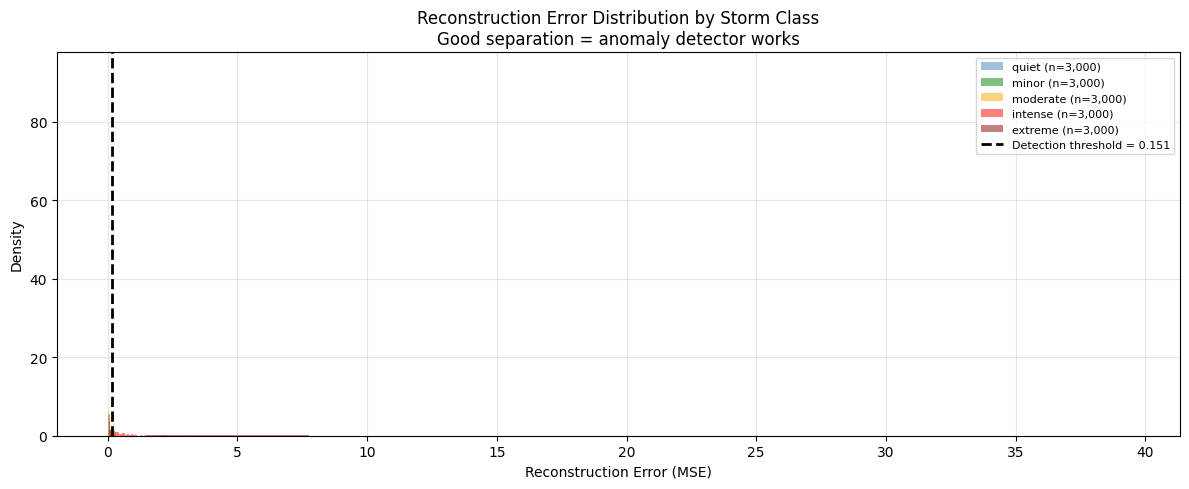


=== Storm Detection Rate (% above threshold) ===
  quiet     : 1.0% detected
  minor     : 5.3% detected
  moderate  : 28.4% detected
  intense   : 63.3% detected
  extreme   : 100.0% detected


In [11]:
# Load best model
model.load_state_dict(torch.load('anomaly_model.pt', map_location=DEVICE))
model.eval()

# Reload full dataset for calibration
print('Reloading enriched.parquet for calibration ...')
df_full = pd.read_parquet(DRIVE_PATH)
for col in ANOMALY_FEATURES:
    df_full[col] = df_full[col].fillna(df_full[col].median())
df_full[ANOMALY_FEATURES] = scaler.transform(df_full[ANOMALY_FEATURES])

def get_recon_errors(df_sub, n_samples=3000):
    """Sample n windows and return per-window MSE errors."""
    X      = df_sub[ANOMALY_FEATURES].values.astype(np.float32)
    errors = []
    limit  = min(n_samples, len(X) - SEQ_LEN)
    for i in range(limit):
        window = torch.tensor(X[i:i + SEQ_LEN]).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            recon = model(window)
        errors.append(torch.mean((window - recon) ** 2).item())
        if i % 500 == 0:
            print(f'  {i}/{limit}', end='\r')
    return np.array(errors)

# ── Compute errors per storm class ──
storm_classes = [
    ('quiet',    df_full['dst'].isna() | (df_full['dst'] > -30)),
    ('minor',    (df_full['dst'] <= -30)  & (df_full['dst'] > -50)),
    ('moderate', (df_full['dst'] <= -50)  & (df_full['dst'] > -100)),
    ('intense',  (df_full['dst'] <= -100) & (df_full['dst'] > -200)),
    ('extreme',  (df_full['dst'] <= -200)),
]

class_errors    = {}
class_thresholds = {}

for name, mask in storm_classes:
    sub = df_full[mask].reset_index(drop=True)
    print(f'\nComputing errors for {name} (n={len(sub):,}) ...')
    errs = get_recon_errors(sub, n_samples=3000)
    class_errors[name] = errs
    class_thresholds[name] = {
        'mean':  float(errs.mean()),
        'std':   float(errs.std()),
        'p50':   float(np.percentile(errs, 50)),
        'p95':   float(np.percentile(errs, 95)),
        'p99':   float(np.percentile(errs, 99)),
    }
    print(f'  mean={errs.mean():.4f}  std={errs.std():.4f}  p95={np.percentile(errs,95):.4f}')

# ── Define score boundaries ──
# Use quiet p99 as the detection threshold
RECON_THRESHOLD = class_thresholds['quiet']['p99']
# Use extreme p50 as the upper bound (score=1.0)
RECON_MAX       = class_thresholds['extreme']['p50']

print(f'\nCalibrated thresholds:')
print(f'  Detection threshold (quiet p99) : {RECON_THRESHOLD:.4f}')
print(f'  Max threshold       (extreme p50): {RECON_MAX:.4f}')

# ── Visualize error distributions per class ──
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue', 'green', 'orange', 'red', 'darkred']
for (name, _), color in zip(storm_classes, colors):
    errs = class_errors[name]
    lo, hi = np.percentile(errs, 1), np.percentile(errs, 99)
    ax.hist(np.clip(errs, lo, hi), bins=60, alpha=0.5,
            color=color, label=f'{name} (n={len(errs):,})', density=True)
ax.axvline(RECON_THRESHOLD, color='black', lw=2, linestyle='--',
           label=f'Detection threshold = {RECON_THRESHOLD:.3f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Reconstruction Error Distribution by Storm Class\n'
             'Good separation = anomaly detector works')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_calibration.png', dpi=150)
plt.show()

print('\n=== Storm Detection Rate (% above threshold) ===')
for name, _ in storm_classes:
    rate = 100 * (class_errors[name] > RECON_THRESHOLD).mean()
    print(f'  {name:10s}: {rate:.1f}% detected')

## Cell 12 — Plot training curves

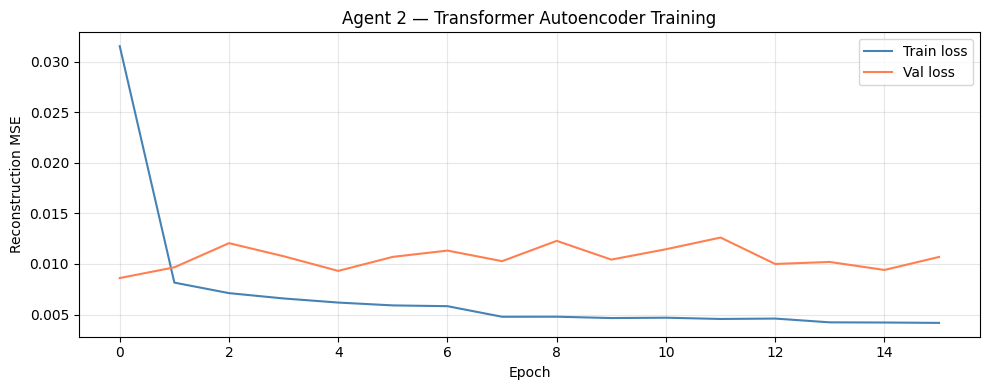

Saved anomaly_training_curve.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train loss', color='steelblue')
ax.plot(val_losses,   label='Val loss',   color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction MSE')
ax.set_title('Agent 2 — Transformer Autoencoder Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_training_curve.png', dpi=150)
plt.show()
print('Saved anomaly_training_curve.png')

## Cell 13 — Save all artifacts

In [13]:
import shutil

# Save scaler
with open('anomaly_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save config with calibrated thresholds
config = {
    'input_size':        len(ANOMALY_FEATURES),
    'seq_len':           SEQ_LEN,
    'd_model':           HIDDEN_SIZE,
    'latent_dim':        LATENT_DIM,
    'nhead':             4,
    'num_layers':        NUM_LAYERS,
    'dropout':           DROPOUT,
    'feature_cols':      ANOMALY_FEATURES,
    'quiet_threshold':   QUIET_DST_THRESHOLD,
    'recon_threshold':   RECON_THRESHOLD,    # quiet p99 — detection boundary
    'recon_max':         RECON_MAX,          # extreme p50 — score=1.0 boundary
    'alert_green':       ALERT_GREEN,
    'alert_yellow':      ALERT_YELLOW,
    'best_val_loss':     float(best_val),
    'class_thresholds':  class_thresholds,   # per-class calibration stats
}
with open('anomaly_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Copy to Drive
for fname in ['anomaly_model.pt', 'anomaly_scaler.pkl', 'anomaly_config.json']:
    shutil.copy(fname, f'{MODELS_DIR}/{fname}')
    print(f'Saved to Drive: {MODELS_DIR}/{fname}')

print('\nAll artifacts saved.')
print(f'Recon threshold : {RECON_THRESHOLD:.4f}')
print(f'Recon max       : {RECON_MAX:.4f}')

Saved to Drive: /content/drive/MyDrive/Solar_Winds/models/anomaly_model.pt
Saved to Drive: /content/drive/MyDrive/Solar_Winds/models/anomaly_scaler.pkl
Saved to Drive: /content/drive/MyDrive/Solar_Winds/models/anomaly_config.json

All artifacts saved.
Recon threshold : 0.1511
Recon max       : 5.1306


## Cell 14 — Download all artifacts

In [14]:
from google.colab import files
import os

artifacts = [
    'anomaly_model.pt',
    'anomaly_scaler.pkl',
    'anomaly_config.json',
    'anomaly_training_curve.png',
    'anomaly_calibration.png',
]

for f in artifacts:
    if os.path.exists(f):
        files.download(f)
        print(f'Downloaded: {f}')
    else:
        print(f'Skipped (not found): {f}')

print('\nDownload complete!')
print('Place model files in models/ folder:')
print('  models/anomaly_model.pt')
print('  models/anomaly_scaler.pkl')
print('  models/anomaly_config.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: anomaly_model.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: anomaly_training_curve.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: anomaly_calibration.png

Download complete!
Place model files in models/ folder:
  models/anomaly_model.pt
  models/anomaly_scaler.pkl
  models/anomaly_config.json
